<a href="https://colab.research.google.com/github/adeniranlj-ui/projects1/blob/main/Decision_Tree_Neural_Network_Practice_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Decision Tree and Neural Network



In [ ]:

# ===== Imports =====
import os
import io
import sys
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Show versions for reproducibility
print("Python:", sys.version.split()[0])
import sklearn, pandas
print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.12.12
pandas: 2.2.2
scikit-learn: 1.6.1


## 1) Load the dataset

In [ ]:
from google.colab import files           # Colab-style file uploader (comment if not using Colab)
uploaded = files.upload()                 # choose SystemAdministrators.csv in the dialog
file_name = "eBay.csv"    # <-- change if your uploaded filename differs
df = pd.read_csv(file_name)      # load CSV into pandas DataFrame


# Optional: add a 1-based row number for inspection/plots
df["Number"] = df.index + 1

# Quick look at the data
df.head()

Saving eBay.csv to eBay (2).csv


,SellerRating,Duration,ClosePrice,OpenPrice,Competitive,EndDay,Currency,Category,Category.Art.Collectibles,Category.Books,...,Category.Coins.Stamps,Category.Computer.Electronics,Category.EverythingElse,Category.Health.Beauty,Category.Home.Garden,Category.Jewelry,Category.Music.Movie.Game,Currency.nonUS,EndDay.Weekend,Number
0,3249,5,0.01,0.01,0,Week,US,Music/Movie/Game,0,0,...,0,0,0,0,0,0,1,0,0,1
1,3249,5,0.01,0.01,0,Week,US,Music/Movie/Game,0,0,...,0,0,0,0,0,0,1,0,0,2
2,3249,5,0.01,0.01,0,Week,US,Music/Movie/Game,0,0,...,0,0,0,0,0,0,1,0,0,3
3,3249,5,0.01,0.01,0,Week,US,Music/Movie/Game,0,0,...,0,0,0,0,0,0,1,0,0,4
4,3249,5,0.01,0.01,0,Week,US,Music/Movie/Game,0,0,...,0,0,0,0,0,0,1,0,0,5


## 2) Remove some predictors

In [ ]:

# Drop textual variables
cols_to_drop = ['Category', 'Currency', 'EndDay']
existing_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=existing_to_drop)
print("Dropped columns:", existing_to_drop)


Dropped columns: ['Category', 'Currency', 'EndDay']


## 3) Train/Validation Split (70/30, random_state=1)

In [ ]:

X = df.drop(columns=['Competitive'])
y = df['Competitive']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, train_size=0.6, random_state=1, stratify=y if len(np.unique(y)) > 1 else None
)

print("Train shape:", X_train.shape, " Valid shape:", X_valid.shape)
# np.bincount counts how many of each integer appear (i.e., 0 and 1 in this case).
# if y_train.dtype.kind in 'iu' checks whether the labels are integers.
# If the labels are non-integers (e.g., strings like "yes", "no"):value_counts().to_dict() counts frequencies per unique value (e.g., 'yes': 2, 'no': 1}).
print("Class distribution (train):", np.bincount(y_train) if y_train.dtype.kind in 'iu' else y_train.value_counts().to_dict())
print("Class distribution (valid):", np.bincount(y_valid) if y_valid.dtype.kind in 'iu' else y_valid.value_counts().to_dict())


Train shape: (1183, 17)  Valid shape: (789, 17)
Class distribution (train): [544 639]
Class distribution (valid): [362 427]


## 4) Fit Decision Tree

In [ ]:

# Control max_depth to avoid overfitting
tree1 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,min_samples_split=20, random_state=1)
tree1.fit(X_train, y_train)

# Variable importance (feature importances)
importances = pd.Series(tree1.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(importances.to_frame('importance'))


,importance
OpenPrice,0.437804
ClosePrice,0.433297
SellerRating,0.045759
Currency.nonUS,0.039185
Number,0.032240
Category.Clothing.Toys,0.011714
Category.Books,0.000000
Category.Art.Collectibles,0.000000
Duration,0.000000
Category.Computer.Electronics,0.000000


### 4-a) Plot the tree

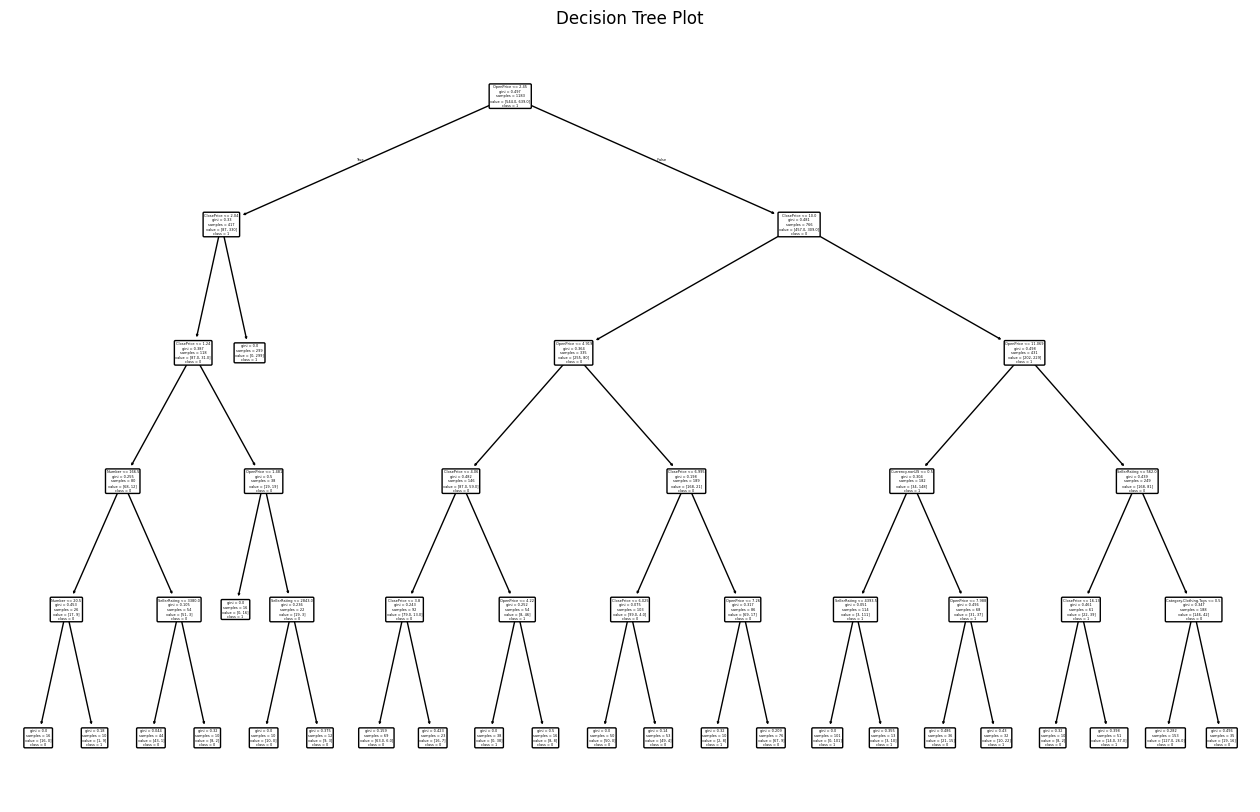

In [ ]:

plt.figure(figsize=(16, 10))
plot_tree(
    tree1,
    feature_names=list(X_train.columns),
    class_names=[str(c) for c in sorted(np.unique(y))],
    filled=False,  # do not force a specific color scheme
    rounded=True
)
plt.title("Decision Tree Plot")
plt.show()


### 4-b) List decision rules

In [ ]:
rules_text = export_text(tree1, feature_names=list(X_train.columns))
print(rules_text)

|--- OpenPrice <= 2.45
|   |--- ClosePrice <= 2.04
|   |   |--- ClosePrice <= 1.24
|   |   |   |--- Number <= 166.50
|   |   |   |   |--- Number <= 20.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Number >  20.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- Number >  166.50
|   |   |   |   |--- SellerRating <= 3380.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- SellerRating >  3380.00
|   |   |   |   |   |--- class: 0
|   |   |--- ClosePrice >  1.24
|   |   |   |--- OpenPrice <= 1.48
|   |   |   |   |--- class: 1
|   |   |   |--- OpenPrice >  1.48
|   |   |   |   |--- SellerRating <= 2843.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- SellerRating >  2843.00
|   |   |   |   |   |--- class: 0
|   |--- ClosePrice >  2.04
|   |   |--- class: 1
|--- OpenPrice >  2.45
|   |--- ClosePrice <= 10.00
|   |   |--- OpenPrice <= 4.92
|   |   |   |--- ClosePrice <= 4.06
|   |   |   |   |--- ClosePrice <= 3.80
|   |   |   |   |   |--- class: 0
|   |   |   |   

In [ ]:
from sklearn.tree import _tree
import numpy as np
import pandas as pd

def concise_rules_summary(model, feature_names, class_names, y_train=None,
                          prob_digits=2, pct_digits=2):
    tree = model.tree_
    n_nodes = tree.node_count
    left = tree.children_left
    right = tree.children_right
    feat_idx = tree.feature
    thr = tree.threshold

    # ---- Build a robust parent map so we can reconstruct FULL paths ----
    parent = np.full(n_nodes, -1, dtype=int)
    is_left_child = np.zeros(n_nodes, dtype=bool)
    stack = [0]
    while stack:
        node = stack.pop()
        l, r = left[node], right[node]
        if l != _tree.TREE_LEAF:
            parent[l] = node
            is_left_child[l] = True
            stack.append(l)
        if r != _tree.TREE_LEAF:
            parent[r] = node
            is_left_child[r] = False
            stack.append(r)

    # Use the model's recorded training count at root as denominator
    n_total = int(tree.n_node_samples[0])

    rows = []
    for node in range(n_nodes):
        # Leaf if feature[node] == TREE_UNDEFINED
        if feat_idx[node] == _tree.TREE_UNDEFINED:
            # Support from the fitted tree (unweighted sample count at this leaf)
            support = int(tree.n_node_samples[node])

            # Class distribution/probabilities
            counts = tree.value[node][0]
            total = counts.sum() if counts is not None else 0
            probs = (counts / total) if total > 0 else counts
            pred = class_names[int(np.argmax(counts))] if total > 0 else class_names[0]

            # --------- FULL PATH: walk leaf -> root, collect every split ----------
            conds_rev = []
            cur = node
            while parent[cur] != -1:
                p = parent[cur]
                fidx = feat_idx[p]
                fname = feature_names[fidx]
                threshold = thr[p]
                if is_left_child[cur]:
                    conds_rev.append(f"{fname} <= {threshold:.2f}")
                else:
                    conds_rev.append(f"{fname} > {threshold:.2f}")
                cur = p
            # reverse to root -> leaf order; DO NOT simplify/merge bounds
            rule_path = " & ".join(reversed(conds_rev)) if conds_rev else "TRUE"

            row = {
                "Pred": pred,
                "Rule_Path": rule_path,
                "Leaf": support,
                "Cover%": (100.0 * support / n_total) if n_total > 0 else np.nan,
            }
            # add Prob_0, Prob_1 (and more if multiclass)
            if probs is not None:
                for i, p in enumerate(probs):
                    row[f"Prob_{i}"] = round(float(p), prob_digits)
            rows.append(row)

    if not rows:
        print("No leaf rules found (is the model fitted and non-empty?).")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    # ensure at least Prob_0/Prob_1 columns exist for binary case
    for c in ["Prob_0", "Prob_1"]:
        if c not in df.columns:
            df[c] = np.nan

    # order columns
    df = df[["Pred", "Prob_0", "Prob_1", "Rule_Path", "Leaf", "Cover%"]]
    df = df.sort_values(["Leaf", "Pred"], ascending=[False, True]).reset_index(drop=True)

    # pretty print with header; keep Cover% precision in printout
    print(f"{'Pred':<5} {'Prob_0':>7} {'Prob_1':>7}  {'Rule_Path':<80} {'Leaf':>6} {'Cover%':>8}")
    for _, r in df.iterrows():
        print(f"{str(r['Pred']):<5} {r['Prob_0']:>7} {r['Prob_1']:>7}  {r['Rule_Path']:<80} {int(r['Leaf']):>6} {r['Cover%']:>7.2f}")
    print(f"\nSum Cover%: {df['Cover%'].sum():.6f}%")

    return df

# Apply the 'consice rule summary' function:
rule_df = concise_rules_summary(tree1, list(X_train.columns), tree1.classes_)


Pred   Prob_0  Prob_1  Rule_Path                                                                          Leaf   Cover%
1         0.0     1.0  OpenPrice <= 2.45 & ClosePrice > 2.04                                               299   25.27
0        0.83    0.17  OpenPrice > 2.45 & ClosePrice > 10.00 & OpenPrice > 11.07 & SellerRating > 562.00 & Category.Clothing.Toys <= 0.50    153   12.93
1         0.0     1.0  OpenPrice > 2.45 & ClosePrice > 10.00 & OpenPrice <= 11.07 & Currency.nonUS <= 0.50 & SellerRating <= 4393.50    101    8.54
0        0.88    0.12  OpenPrice > 2.45 & ClosePrice <= 10.00 & OpenPrice > 4.92 & ClosePrice > 6.99 & OpenPrice > 7.26     76    6.42
0        0.91    0.09  OpenPrice > 2.45 & ClosePrice <= 10.00 & OpenPrice <= 4.92 & ClosePrice <= 4.06 & ClosePrice <= 3.80     69    5.83
0        0.92    0.08  OpenPrice > 2.45 & ClosePrice <= 10.00 & OpenPrice > 4.92 & ClosePrice <= 6.99 & ClosePrice > 6.03     53    4.48
1        0.27    0.73  OpenPrice > 2.45 & ClosePr

### 4-c) Confusion matrix on validation data

Accuracy: 0.8757921419518377

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87       362
           1       0.93      0.84      0.88       427

    accuracy                           0.88       789
   macro avg       0.88      0.88      0.88       789
weighted avg       0.88      0.88      0.88       789



,pred_0,pred_1
true_0,333,29
true_1,69,358


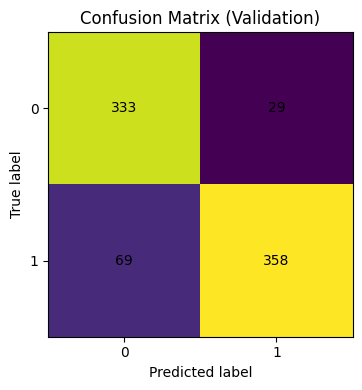

In [ ]:

y_pred1 = tree1.predict(X_valid)
cm1 = confusion_matrix(y_valid, y_pred1, labels=sorted(np.unique(y)))
acc1 = accuracy_score(y_valid, y_pred1)
print("Accuracy:", acc1)
print("\nClassification report:\n", classification_report(y_valid, y_pred1))

# Show confusion matrix as a table and a simple image (no custom colors)
cm_df1 = pd.DataFrame(cm1, index=[f"true_{c}" for c in sorted(np.unique(y))],
                         columns=[f"pred_{c}" for c in sorted(np.unique(y))])
display(cm_df1)

plt.figure(figsize=(4, 4))
plt.imshow(cm1, interpolation='nearest')
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(ticks=range(len(np.unique(y))), labels=sorted(np.unique(y)))
plt.yticks(ticks=range(len(np.unique(y))), labels=sorted(np.unique(y)))
for i in range(cm1.shape[0]):
    for j in range(cm1.shape[1]):
        plt.text(j, i, cm1[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


In [ ]:
# Show predictors used in the tree
#-2 indicate a leaf node, i.e., a node that does not split on any feature.
#In scikit-learn’s DecisionTreeClassifier or DecisionTreeRegressor, the fitted model stores its internal structure in tree1.tree_
used_features = [X_train.columns[i] for i in tree1.tree_.feature if i != -2]
print(set(used_features))

{'Number', 'ClosePrice', 'OpenPrice', 'SellerRating'}


## 5) Second tree without a Predictor

In [ ]:

if 'OpenPrice' in df.columns:
    df2 = df.drop(columns=['OpenPrice'])
else:
    print("Column 'OpenPrice' not found; proceeding with the same features as df.")
    df2 = df.copy()

X2 = df2.drop(columns=['Competitive'])
y2 = df2['Competitive']

X2_train, X2_valid, y2_train, y2_valid = train_test_split(
    X2, y2, train_size=0.6, random_state=1, stratify=y2 if len(np.unique(y2)) > 1 else None
)

tree2 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,min_samples_split=10, random_state=1)
tree2.fit(X2_train, y2_train)

print("Feature importances (model without OpenPrice):")
importances2 = pd.Series(tree2.feature_importances_, index=X2_train.columns).sort_values(ascending=False)
display(importances2.to_frame('importance'))

Feature importances (model without OpenPrice):


,importance
Number,0.488654
ClosePrice,0.426808
SellerRating,0.041766
Category.EverythingElse,0.029820
Currency.nonUS,0.012951
Category.Books,0.000000
Duration,0.000000
Category.Art.Collectibles,0.000000
Category.Computer.Electronics,0.000000
Category.Coins.Stamps,0.000000


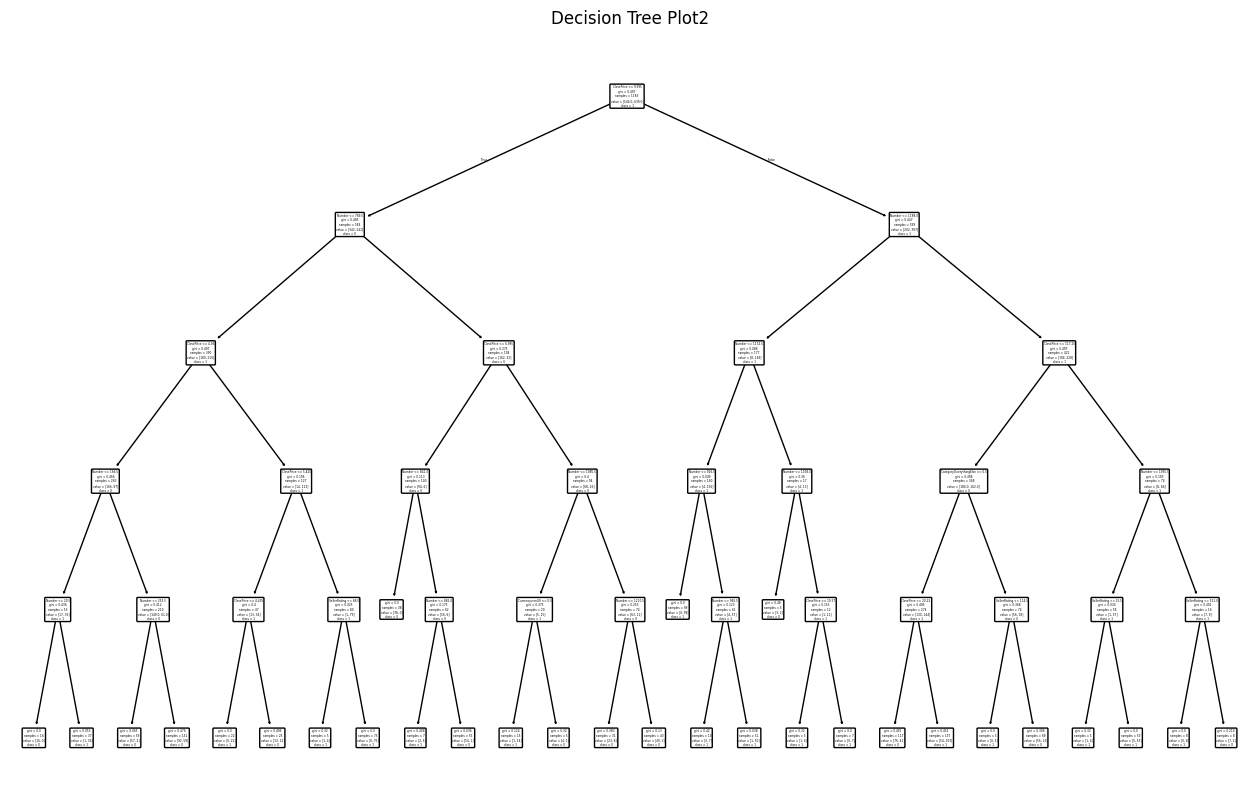

In [ ]:
# Plot
plt.figure(figsize=(16, 10))
plot_tree(
    tree2,
    feature_names=list(X2_train.columns),
    class_names=[str(c) for c in sorted(np.unique(y2))],
    filled=False,  # do not force a specific color scheme
    rounded=True
)
plt.title("Decision Tree Plot2")
plt.show()

In [ ]:
from sklearn.tree import _tree
import numpy as np
import pandas as pd

def concise_rules_summary(model, feature_names, class_names, y_train=None,
                          prob_digits=2, pct_digits=2):
    tree = model.tree_
    n_nodes = tree.node_count
    left = tree.children_left
    right = tree.children_right
    feat_idx = tree.feature
    thr = tree.threshold

    # ---- Build a robust parent map so we can reconstruct FULL paths ----
    parent = np.full(n_nodes, -1, dtype=int)
    is_left_child = np.zeros(n_nodes, dtype=bool)
    stack = [0]
    while stack:
        node = stack.pop()
        l, r = left[node], right[node]
        if l != _tree.TREE_LEAF:
            parent[l] = node
            is_left_child[l] = True
            stack.append(l)
        if r != _tree.TREE_LEAF:
            parent[r] = node
            is_left_child[r] = False
            stack.append(r)

    # Use the model's recorded training count at root as denominator
    n_total = int(tree.n_node_samples[0])

    rows = []
    for node in range(n_nodes):
        # Leaf if feature[node] == TREE_UNDEFINED
        if feat_idx[node] == _tree.TREE_UNDEFINED:
            # Support from the fitted tree (unweighted sample count at this leaf)
            support = int(tree.n_node_samples[node])

            # Class distribution/probabilities
            counts = tree.value[node][0]
            total = counts.sum() if counts is not None else 0
            probs = (counts / total) if total > 0 else counts
            pred = class_names[int(np.argmax(counts))] if total > 0 else class_names[0]

            # --------- FULL PATH: walk leaf -> root, collect every split ----------
            conds_rev = []
            cur = node
            while parent[cur] != -1:
                p = parent[cur]
                fidx = feat_idx[p]
                fname = feature_names[fidx]
                threshold = thr[p]
                if is_left_child[cur]:
                    conds_rev.append(f"{fname} <= {threshold:.2f}")
                else:
                    conds_rev.append(f"{fname} > {threshold:.2f}")
                cur = p
            # reverse to root -> leaf order; DO NOT simplify/merge bounds
            rule_path = " & ".join(reversed(conds_rev)) if conds_rev else "TRUE"

            row = {
                "Pred": pred,
                "Rule_Path": rule_path,
                "Leaf": support,
                "Cover%": (100.0 * support / n_total) if n_total > 0 else np.nan,
            }
            # add Prob_0, Prob_1 (and more if multiclass)
            if probs is not None:
                for i, p in enumerate(probs):
                    row[f"Prob_{i}"] = round(float(p), prob_digits)
            rows.append(row)

    if not rows:
        print("No leaf rules found (is the model fitted and non-empty?).")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    # ensure at least Prob_0/Prob_1 columns exist for binary case
    for c in ["Prob_0", "Prob_1"]:
        if c not in df.columns:
            df[c] = np.nan

    # order columns
    df = df[["Pred", "Prob_0", "Prob_1", "Rule_Path", "Leaf", "Cover%"]]
    df = df.sort_values(["Leaf", "Pred"], ascending=[False, True]).reset_index(drop=True)

    # pretty print with header; keep Cover% precision in printout
    print(f"{'Pred':<5} {'Prob_0':>7} {'Prob_1':>7}  {'Rule_Path':<80} {'Leaf':>6} {'Cover%':>8}")
    for _, r in df.iterrows():
        print(f"{str(r['Pred']):<5} {r['Prob_0']:>7} {r['Prob_1']:>7}  {r['Rule_Path']:<80} {int(r['Leaf']):>6} {r['Cover%']:>7.2f}")
    print(f"\nSum Cover%: {df['Cover%'].sum():.6f}%")

    return df

# Apply the 'consice rule summary' function:
rule_df = concise_rules_summary(tree2, list(X_train.columns), tree2.classes_)

Pred   Prob_0  Prob_1  Rule_Path                                                                          Leaf   Cover%
1        0.34    0.66  ClosePrice > 9.99 & EndDay.Weekend > 1188.00 & ClosePrice <= 117.25 & Category.Computer.Electronics <= 0.50 & ClosePrice > 20.22    157   13.27
0        0.61    0.39  ClosePrice <= 9.99 & EndDay.Weekend <= 769.50 & ClosePrice <= 4.06 & EndDay.Weekend > 166.50 & EndDay.Weekend > 253.50    151   12.76
0        0.65    0.35  ClosePrice > 9.99 & EndDay.Weekend > 1188.00 & ClosePrice <= 117.25 & Category.Computer.Electronics <= 0.50 & ClosePrice <= 20.22    117    9.89
1         0.0     1.0  ClosePrice > 9.99 & EndDay.Weekend <= 1188.00 & EndDay.Weekend <= 1132.50 & EndDay.Weekend <= 926.50     99    8.37
1         0.0     1.0  ClosePrice <= 9.99 & EndDay.Weekend <= 769.50 & ClosePrice > 4.06 & ClosePrice > 5.42 & SellerRating > 68.00     75    6.34
0        0.81    0.19  ClosePrice > 9.99 & EndDay.Weekend > 1188.00 & ClosePrice <= 117.25 & Category.

In [ ]:
rules_text = export_text(tree2, feature_names=list(X2_train.columns))
print(rules_text)

|--- ClosePrice <= 9.99
|   |--- Number <= 769.50
|   |   |--- ClosePrice <= 4.06
|   |   |   |--- Number <= 166.50
|   |   |   |   |--- Number <= 20.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Number >  20.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- Number >  166.50
|   |   |   |   |--- Number <= 253.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Number >  253.50
|   |   |   |   |   |--- class: 0
|   |   |--- ClosePrice >  4.06
|   |   |   |--- ClosePrice <= 5.42
|   |   |   |   |--- ClosePrice <= 4.43
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- ClosePrice >  4.43
|   |   |   |   |   |--- class: 0
|   |   |   |--- ClosePrice >  5.42
|   |   |   |   |--- SellerRating <= 68.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- SellerRating >  68.00
|   |   |   |   |   |--- class: 1
|   |--- Number >  769.50
|   |   |--- ClosePrice <= 6.99
|   |   |   |--- Number <= 841.00
|   |   |   |   |--- class: 0
|   |   |   |--- Number >  841.00
| 


Accuracy (no Predicotr1): 0.7934093789607097

Classification report (no Predicotr1):
               precision    recall  f1-score   support

           0       0.74      0.85      0.79       362
           1       0.85      0.75      0.80       427

    accuracy                           0.79       789
   macro avg       0.80      0.80      0.79       789
weighted avg       0.80      0.79      0.79       789



,pred_0,pred_1
true_0,306,56
true_1,107,320


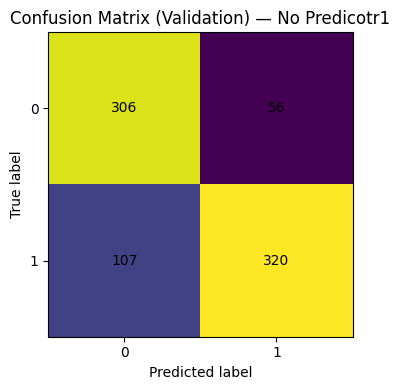

In [ ]:
# Confusion matrix
y2_pred = tree2.predict(X2_valid)
cm2 = confusion_matrix(y2_valid, y2_pred, labels=sorted(np.unique(y2)))
acc2 = accuracy_score(y2_valid, y2_pred)
print("\nAccuracy (no Predicotr1):", acc2)
print("\nClassification report (no Predicotr1):\n", classification_report(y2_valid, y2_pred))

cm_df2 = pd.DataFrame(cm2, index=[f"true_{c}" for c in sorted(np.unique(y2))],
                         columns=[f"pred_{c}" for c in sorted(np.unique(y2))])
display(cm_df2)

plt.figure(figsize=(4, 4))
plt.imshow(cm2, interpolation='nearest')
plt.title("Confusion Matrix (Validation) — No Predicotr1")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(ticks=range(len(np.unique(y2))), labels=sorted(np.unique(y2)))
plt.yticks(ticks=range(len(np.unique(y2))), labels=sorted(np.unique(y2)))
for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        plt.text(j, i, cm2[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

In [ ]:
# Show predictors used in the tree
feature_names2 = list(getattr(tree2, "feature_names_in_", X2_train.columns))
used_features2 = {feature_names2[i] for i in tree2.tree_.feature if i != _tree.TREE_UNDEFINED}
print(used_features2)

{'Number', 'ClosePrice', 'SellerRating', 'Currency.nonUS'}


## Neural Network

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Define a simple feedforward neural network
nn = MLPClassifier(hidden_layer_sizes=(5, 4),  # first layer: 3 neurons (parameters), second layer: 6 neurons (parameters), third layer: 4 neurons (parameters)
                   activation='relu',          # ReLU activation function
                   solver='adam',              # optimizer
                   max_iter=1000,               # number of training iterations (epochs)
                   random_state=42)            # Store the andom seed for the model, controlling how randomness is handled
                                               #(e.g., weight initialization, shuffling of data) to ensure reproducibility

# Train the neural network
nn.fit(X_train, y_train)

# Predict on valid dataset
y_pred_nn = nn.predict(X_valid)

# Evaluate accuracy
print("Neural Network Accuracy:", accuracy_score(y_valid, y_pred_nn))

Neural Network Accuracy: 0.6134347275031685


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_valid, y_pred_nn)
cm_df = pd.DataFrame(cm,
                     index=[f"true_{c}" for c in np.unique(y_valid)],
                     columns=[f"pred_{c}" for c in np.unique(y_valid)])
display(cm_df)

,pred_0,pred_1
true_0,124,238
true_1,67,360


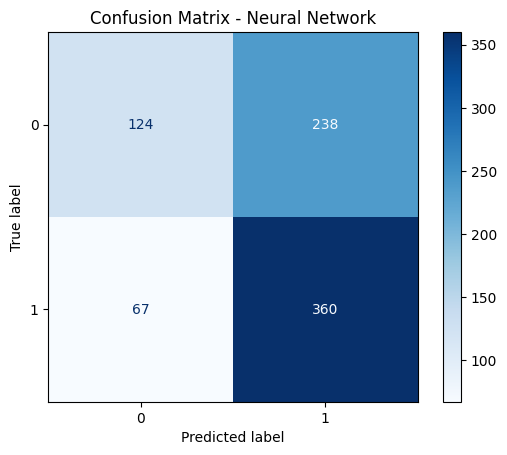

In [ ]:
# Fancy confusion matrix
cm = confusion_matrix(y_valid, y_pred_nn, labels=nn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nn.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Neural Network")
plt.show()